In [1]:
##pip install scikit-learn pandas matplotlib seaborn
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay)
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
"""Load the SMS dataset (or use the built‑in fallback)
Expected columns: label (ham/spam) and text.

Set CSV_PATH = 'sms_spam.csv' (or your local file).

If not found, the code auto‑creates a tiny synthetic sample so the pipeline runs."""
from pathlib import Path
CSV_PATH = Path('sms_spam.csv')

In [3]:
import pandas as pd
import io

# 1. Create sample data mimicking the UCI SMS Spam Collection dataset
data = """type,text
ham,Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham,U dun say so early hor... U c already then say...
ham,Nah I don't think he goes to usf, he lives around here though
spam,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
ham,Even my brother is not like to speak with me. They treat me like aids patent.
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
spam,WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
spam,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030
ham,I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
"""

# 2. Write this data to a CSV file named 'sms_spam.csv'
with open('sms_spam.csv', 'w', encoding='utf-8') as f:
    f.write(data)

print("Successfully created 'sms_spam.csv'")

# 3. Populate dataframe df by reading the CSV
df = pd.read_csv('sms_spam.csv')

# Display the first few rows to verify
print(df.head())

# Optional: Check the shape and class distribution
print(f"\nDataFrame Shape: {df.shape}")
print("\nClass Distribution:")
print(df['type'].value_counts())


Successfully created 'sms_spam.csv'
                                                   type  \
ham                               Go until jurong point   
spam  Free entry in 2 a wkly comp to win FA Cup fina...   
ham   U dun say so early hor... U c already then say...   
ham                    Nah I don't think he goes to usf   
spam  FreeMsg Hey there darling it's been 3 week's n...   

                                                   text  
ham    crazy.. Available only in bugis n great world...  
spam                                                NaN  
ham                                                 NaN  
ham                         he lives around here though  
spam                                       £1.50 to rcv  

DataFrame Shape: (10, 2)

Class Distribution:
type
Go until jurong point                                                                                                                                               1
Free entry in 2 a wkly comp to win FA Cup f

Accuracy: 0.50
ROC AUC Score: 1.00

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         1
        Spam       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

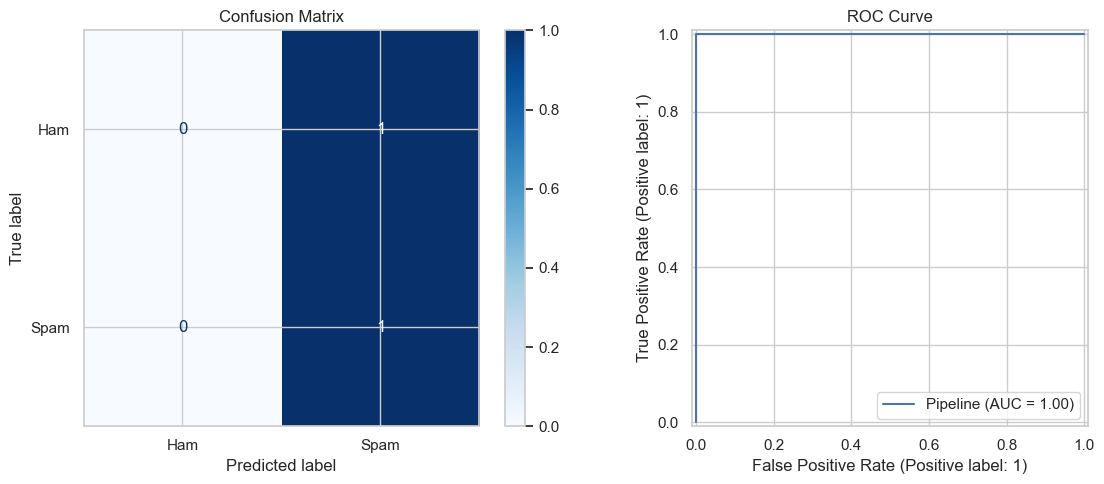

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# 1. Load the dataset
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab17\sms_spam.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# 2. Preprocessing
df['label'] = df['type'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 4. Define and Train Pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(min_df=1, stop_words='english')),
    ('classifier', MultinomialNB())
])

pipeline.fit(X_train, y_train)

# 5. Predictions
y_pred = pipeline.predict(X_test)
# Get probabilities for the positive class (Spam) for ROC calculation
y_proba = pipeline.predict_proba(X_test)[:, 1]

# 6. Evaluation Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# 7. Visualization (Confusion Matrix + ROC Curve)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp_cm.plot(cmap=plt.cm.Blues, ax=ax1)
ax1.set_title("Confusion Matrix")

# Plot ROC Curve
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax2)
ax2.set_title("ROC Curve")

plt.tight_layout()
plt.show()


--- CountVectorizer (Baseline) ---
Accuracy: 0.50
ROC AUC:  1.00
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         1
        Spam       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

------------------------------
--- TF-IDF ---
Accuracy: 0.50
ROC AUC:  1.00
              precision    recall  f1-score   support

         Ham       0.50      1.00      0.67         1
        Spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

------------------------------


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

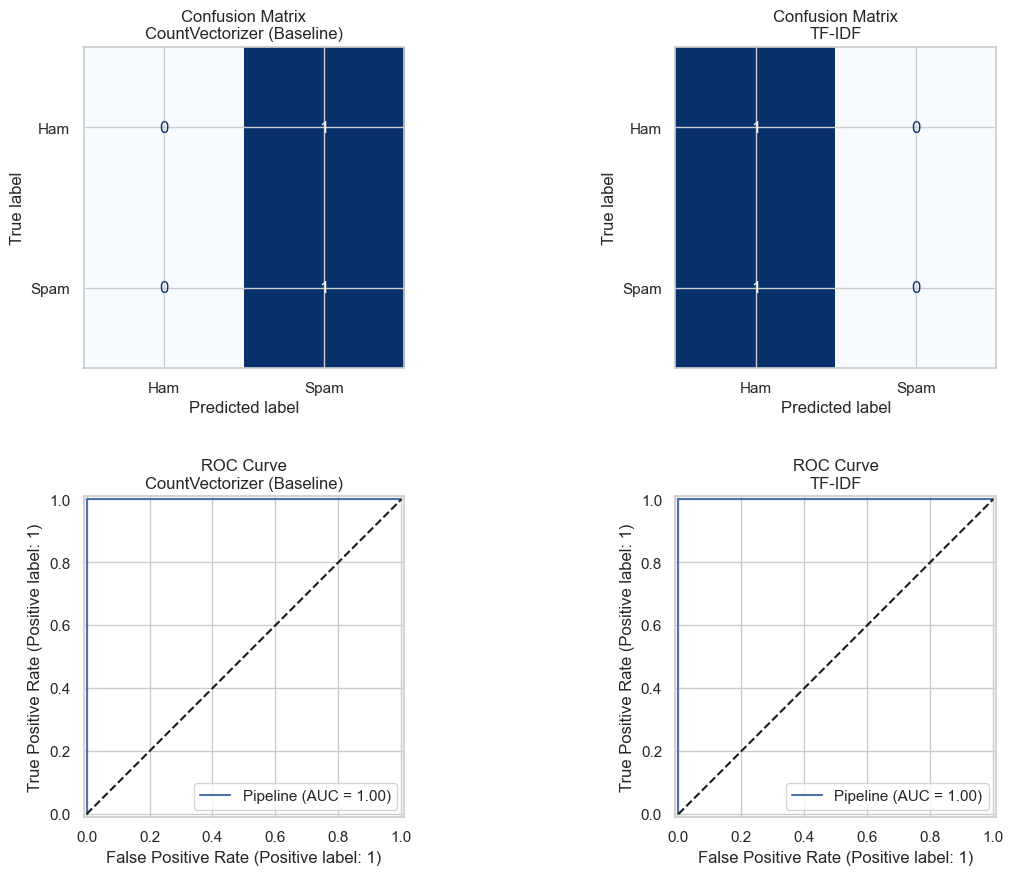

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# 1. Load the dataset
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab17\sms_spam.csv'
# Using 'utf-8-sig' to handle BOM if present
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# 2. Preprocessing
df['label'] = df['type'].map({'ham': 0, 'spam': 1})
X = df['text']
y = df['label']

# 3. Train-Test Split
# Stratify is crucial for small datasets to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 4. Define Pipelines
# Pipeline 1: Baseline (Bag of Words)
pipe_cv = Pipeline([
    ('vec', CountVectorizer(min_df=1, stop_words='english')),
    ('nb', MultinomialNB())
])

# Pipeline 2: TF-IDF
# TfidfVectorizer converts a collection of raw documents to a matrix of TF-IDF features.
pipe_tfidf = Pipeline([
    ('vec', TfidfVectorizer(min_df=1, stop_words='english')),
    ('nb', MultinomialNB())
])

models = {
    "CountVectorizer (Baseline)": pipe_cv,
    "TF-IDF": pipe_tfidf
}

# 5. Train, Evaluate, and Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.2f}")
    print(f"ROC AUC:  {auc:.2f}")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    print("-" * 30)
    
    # Plot Confusion Matrix (Row 0)
    cm = confusion_matrix(y_test, y_pred)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp_cm.plot(cmap=plt.cm.Blues, ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(f"Confusion Matrix\n{name}")
    
    # Plot ROC Curve (Row 1)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1, i])
    axes[1, i].set_title(f"ROC Curve\n{name}")
    axes[1, i].plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)')

plt.show()


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab17\sms_spam.csv'
# encoding='utf-8-sig' handles potential BOM characters
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# 2. Preprocessing
df['label'] = df['type'].map({'ham': 0, 'spam': 1})
X = df['text']
y = df['label']

# 3. Train-Test Split
# Stratify is crucial here to ensure both classes are present in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 4. Define the Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=1)),
    ('nb', MultinomialNB())
])

# 5. Define Parameter Grid
# 'tfidf__ngram_range': (1, 1) = unigrams only, (1, 2) = unigrams + bigrams
# 'nb__alpha': Smoothing parameter (0.0 = no smoothing, 1.0 = Laplace smoothing)
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.5, 1.0, 2.0]
}

# 6. Run GridSearchCV
# cv=2 is used because the sample dataset is very small. Use cv=5 for real data.
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 7. Display Results
print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.3f}")

# 8. Evaluate Best Model on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Starting Grid Search...
Fitting 2 folds for each of 8 candidates, totalling 16 fits

Best Parameters found: {'nb__alpha': 0.1, 'tfidf__ngram_range': (1, 1)}
Best Cross-Validation Accuracy: 0.625

Test Set Evaluation:
Accuracy: 0.50
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         1
        Spam       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. Load and Preprocess Data
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab17\sms_spam.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df['label'] = df['type'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label']

# 2. Train the Model
# We use a pipeline to ensure preprocessing matches training
pipeline = Pipeline([
    ('vec', TfidfVectorizer(stop_words='english', min_df=1)),
    ('nb', MultinomialNB(alpha=0.1)) # Low alpha for this small dataset
])

pipeline.fit(X, y)

# 3. Extract Model Components
vectorizer = pipeline.named_steps['vec']
classifier = pipeline.named_steps['nb']

# Get feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()

# Get log probabilities: shape is (2, n_features)
# Row 0 = Ham, Row 1 = Spam
feature_log_prob = classifier.feature_log_prob_

# 4. Calculate "Spamminess" Score
# The difference between log(P(word|Spam)) and log(P(word|Ham))
# A high positive number means the word is much more likely in Spam.
# A high negative number means the word is much more likely in Ham.
spamminess_score = feature_log_prob[1] - feature_log_prob[0]

# Create a DataFrame for easy viewing
tokens_df = pd.DataFrame({
    'token': feature_names,
    'log_prob_ham': feature_log_prob[0],
    'log_prob_spam': feature_log_prob[1],
    'spam_vs_ham_ratio': spamminess_score
})

# 5. Display Results

print("--- Top 10 Tokens Most Predictive of SPAM ---")
# Sort by ratio descending
top_spam = tokens_df.sort_values(by='spam_vs_ham_ratio', ascending=False).head(10)
print(top_spam[['token', 'spam_vs_ham_ratio']])

print("\n--- Top 10 Tokens Most Predictive of HAM ---")
# Sort by ratio ascending
top_ham = tokens_df.sort_values(by='spam_vs_ham_ratio', ascending=True).head(10)
print(top_ham[['token', 'spam_vs_ham_ratio']])

print("\n--- Top 10 Most Frequent Tokens in SPAM (by weight) ---")
# Sort by raw spam probability
freq_spam = tokens_df.sort_values(by='log_prob_spam', ascending=False).head(10)
print(freq_spam[['token', 'log_prob_spam']])


--- Top 10 Tokens Most Predictive of SPAM ---
      token  spam_vs_ham_ratio
32     free           1.855901
48   mobile           1.692334
82   update           1.692334
17    claim           1.689963
72      std           1.597533
29    entry           1.571668
30       fa           1.571668
33  freemsg           1.313360
35      fun           1.313360
38      hey           1.313360

--- Top 10 Tokens Most Predictive of HAM ---
         token  spam_vs_ham_ratio
66         say          -2.177731
57       point          -2.119000
42      jurong          -2.119000
25         don          -2.083568
46       melle          -1.773642
14  callertune          -1.773642
51         nah          -1.753763
36        goes          -1.753763
77       think          -1.753763
83         usf          -1.753763

--- Top 10 Most Frequent Tokens in SPAM (by weight) ---
      token  log_prob_spam
32     free      -3.608671
48   mobile      -3.772238
82   update      -3.772238
17    claim      -3.774608
7

In [29]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. Load and Preprocess Data
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab17\sms_spam.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df['label'] = df['type'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label']

# 2. Train the Model
# We use a pipeline to ensure preprocessing matches training
pipeline = Pipeline([
    ('vec', TfidfVectorizer(stop_words='english', min_df=1)),
    ('nb', MultinomialNB(alpha=0.1)) # Low alpha for this small dataset
])

pipeline.fit(X, y)

# 3. Extract Model Components
vectorizer = pipeline.named_steps['vec']
classifier = pipeline.named_steps['nb']

# Get feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()

# Get log probabilities: shape is (2, n_features)
# Row 0 = Ham, Row 1 = Spam
feature_log_prob = classifier.feature_log_prob_

# 4. Calculate "Spamminess" Score
# The difference between log(P(word|Spam)) and log(P(word|Ham))
# A high positive number means the word is much more likely in Spam.
# A high negative number means the word is much more likely in Ham.
spamminess_score = feature_log_prob[1] - feature_log_prob[0]

# Create a DataFrame for easy viewing
tokens_df = pd.DataFrame({
    'token': feature_names,
    'log_prob_ham': feature_log_prob[0],
    'log_prob_spam': feature_log_prob[1],
    'spam_vs_ham_ratio': spamminess_score
})

# 5. Display Results

print("--- Top 10 Tokens Most Predictive of SPAM ---")
# Sort by ratio descending
top_spam = tokens_df.sort_values(by='spam_vs_ham_ratio', ascending=False).head(10)
print(top_spam[['token', 'spam_vs_ham_ratio']])

print("\n--- Top 10 Tokens Most Predictive of HAM ---")
# Sort by ratio ascending
top_ham = tokens_df.sort_values(by='spam_vs_ham_ratio', ascending=True).head(10)
print(top_ham[['token', 'spam_vs_ham_ratio']])

print("\n--- Top 10 Most Frequent Tokens in SPAM (by weight) ---")
# Sort by raw spam probability
freq_spam = tokens_df.sort_values(by='log_prob_spam', ascending=False).head(10)
print(freq_spam[['token', 'log_prob_spam']])


--- Top 10 Tokens Most Predictive of SPAM ---
      token  spam_vs_ham_ratio
32     free           1.855901
48   mobile           1.692334
82   update           1.692334
17    claim           1.689963
72      std           1.597533
29    entry           1.571668
30       fa           1.571668
33  freemsg           1.313360
35      fun           1.313360
38      hey           1.313360

--- Top 10 Tokens Most Predictive of HAM ---
         token  spam_vs_ham_ratio
66         say          -2.177731
57       point          -2.119000
42      jurong          -2.119000
25         don          -2.083568
46       melle          -1.773642
14  callertune          -1.773642
51         nah          -1.753763
36        goes          -1.753763
77       think          -1.753763
83         usf          -1.753763

--- Top 10 Most Frequent Tokens in SPAM (by weight) ---
      token  log_prob_spam
32     free      -3.608671
48   mobile      -3.772238
82   update      -3.772238
17    claim      -3.774608
7